In [ ]:
# Instalar cellpylib si no está instalado
!pip install cellpylib

  Preparing metadata (setup.py) ... done
  Created wheel for cellpylib: filename=cellpylib-2.4.0-py3-none-any.whl size=37922 sha256=bbdc0a7a6b6856ce1869aaa3c51f463193ed71b26070a346e547c096291f6b58
  Stored in directory: /root/.cache/pip/wheels/71/61/57/bbbbd5e8b79d6898242d075bd552bafab484034c3fcf710177
Successfully built cellpylib


# 1. Identificación y Descripción de las Clases de Wolfram

 Wolfram clasificó los autómatas celulares unidimensionales en cuatro clases según su comportamiento asintótico a largo plazo, partiendo de condiciones iniciales aleatorias:  

 Clase I (Evolución hacia un estado homogéneo): El sistema evita el caos de forma absoluta. Casi cualquier condición inicial evoluciona rápidamente hacia un estado estacionario uniforme y único (por ejemplo, todas las celdas muertas o todas vivas). Regla típica: Regla 32.  

 Clase II (Evolución hacia estructuras periódicas o estables): El sistema genera estructuras locales separadas que permanecen fijas en el tiempo o ciclan periódicamente entre unos pocos estados. Hay una filtración de la información inicial, pero no se propaga. Regla típica: Regla 4.  

 Clase III (Evolución caótica o no periódica): El sistema exhibe un comportamiento aperiódico y desordenado. Pequeñas perturbaciones en la condición inicial tienden a propagarse indefinidamente por todo el espacio, destruyendo cualquier patrón local predecible. Regla típica: Regla 30.  

 Clase IV (Evolución hacia estructuras complejas localizadas): Es la frontera entre el orden y el caos (estado crítico). Se forman estructuras locales complejas que interactúan entre sí, viajan a través del espacio celular y son capaces de transmitir información, lo que permite la computación universal. Regla típica: Regla 110.  

SIMULADOR CONFIGURABLE DE AUTÓMATAS CELULARES 1D
1. Introduce el radio de vecindario r (ej. 1, 2, 3): 1
   -> Para r=1, el espacio de vecindario es de 3 celdas.
   -> Puedes elegir una regla entre el rango [0 y 255].
2. Introduce el número de regla: 90

3. Selecciona el tipo de condición de frontera (Bordes):
   [1] Cíclico / Periódico (Los extremos se conectan formando un toroide)
   [2] Límite Fijo / Muerto (Las celdas fuera del límite se consideran apagadas/0)
   Elige una opción (1 o 2): 2

[Configuración Exitosa]
 -> Regla: 90 | Radio: 1
 -> Frontera: Límite Fijo (Muerto)
 -> Diagnóstico: Clase III (Comportamiento caótico/aperiódico)

Generando matriz visual espacio-tiempo...


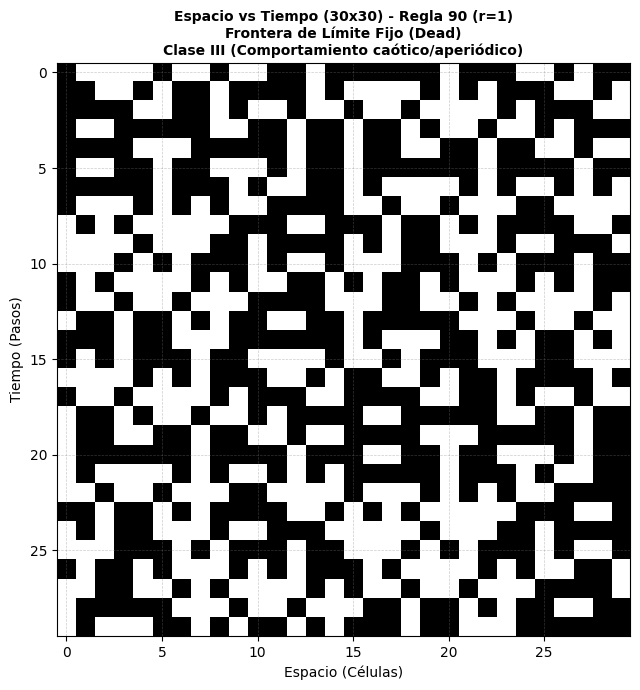

In [ ]:
#tarea 01

import cellpylib as cpl
import numpy as np
import matplotlib.pyplot as plt

# DICCIONARIO COMPLETO (256 REGLAS PARA R=1)
DICCIONARIO_COMPLETO_REGLAS = {
    "Clase I (Evolución hacia estado homogéneo)": [
        0, 8, 32, 40, 64, 72, 96, 104, 128, 136, 160, 168, 192, 200, 224, 232,
        4, 12, 36, 44, 68, 76, 100, 108, 132, 140, 164, 172, 196, 204, 228, 236,
        250, 252, 254, 255
    ],
    "Clase II (Estructuras periódicas o estables)": [
        1, 2, 3, 5, 6, 7, 9, 10, 11, 13, 14, 15, 16, 17, 19, 21, 23, 24, 25, 26, 27, 28, 29,
        33, 34, 35, 37, 38, 39, 41, 42, 43, 46, 47, 50, 51, 52, 53, 55, 56, 57, 58, 59, 61, 62, 63,
        65, 66, 67, 69, 70, 71, 73, 74, 75, 77, 78, 79, 80, 81, 82, 83, 84, 85, 87, 88, 89, 91, 92,
        93, 94, 95, 97, 98, 99, 101, 102, 103, 107, 111, 112, 113, 114, 115, 116, 117, 118, 119,
        121, 123, 125, 127, 130, 131, 133, 134, 135, 138, 139, 141, 142, 143, 144, 145, 148, 149,
        152, 153, 154, 155, 156, 157, 158, 159, 162, 163, 165, 166, 167, 170, 171, 173, 174, 175,
        176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 194, 197,
        198, 199, 201, 202, 203, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217,
        218, 219, 220, 221, 222, 223, 226, 227, 229, 230, 231, 233, 234, 235, 237, 238, 239, 240,
        241, 242, 243, 244, 245, 246, 247, 248, 249, 251, 253
    ],
    "Clase III (Comportamiento caótico/aperiódico)": [
        18, 22, 30, 45, 60, 90, 105, 122, 126, 146, 150, 129, 161, 169, 151, 225
    ],
    "Clase IV (Estructuras complejas/Gliders intermitentes)": [
        54, 110, 137, 147, 193, 204
    ]
}

def determinar_clase(regla, radio):
    """Identifica la clase de Wolfram usando el diccionario corregido."""
    if radio != 1:
        return "Clasificación analítica compleja (Las clases de Wolfram clásicas aplican estrictamente a r=1)"
    for clase, lista_reglas in DICCIONARIO_COMPLETO_REGLAS.items():
        if regla in lista_reglas:
            return clase
    return "Clase no indexada"

# MENÚ INTERACTIVO DE CONFIGURACIÓN

print("SIMULADOR CONFIGURABLE DE AUTÓMATAS CELULARES 1D")

try:
    # 1. Selección del Radio r
    radio_r = int(input("1. Introduce el radio de vecindario r (ej. 1, 2, 3): "))
    if radio_r < 1:
        raise ValueError("El radio r debe ser un entero mayor o igual a 1.")

    # Calcular el número máximo de reglas permitidas para el radio r dado: 2^(2^(2r+1))
    num_vecinos = 2 * radio_r + 1
    max_reglas = 2**num_vecinos
    print(f"   -> Para r={radio_r}, el espacio de vecindario es de {num_vecinos} celdas.")

    # Manejo de desbordamiento visual para el texto descriptivo de reglas gigantes
    if max_reglas < 31:
        print(f"   -> Puedes elegir una regla entre el rango [0 y {2**max_reglas - 1}].")
    else:
        print(f"   -> Rango de reglas permitidas: [0 y 2^{max_reglas} - 1].")

    # 2. Selección de la Regla
    regla_usuario = int(input(f"2. Introduce el número de regla: "))
    if regla_usuario < 0:
        raise ValueError("El número de regla no puede ser negativo.")
    if max_reglas < 31 and not (0 <= regla_usuario <= (2**max_reglas - 1)):
        raise ValueError(f"Regla fuera de rango para r={radio_r}.")

    # 3. Selección del Tipo de Borde
    print("\n3. Selecciona el tipo de condición de frontera (Bordes):")
    print("   [1] Cíclico / Periódico (Los extremos se conectan formando un toroide)")
    print("   [2] Límite Fijo / Muerto (Las celdas fuera del límite se consideran apagadas/0)")
    opcion_borde = int(input("   Elige una opción (1 o 2): "))
    if opcion_borde not in [1, 2]:
        raise ValueError("Opción de borde inválida.")

except ValueError as e:
    print(f"\n[Error de Entrada]: {e} Reinicia el script.")
    exit()

# Determinar comportamiento teórico si r=1
clase_detectada = determinar_clase(regla_usuario, radio_r)
print(f"\n[Configuración Exitosa]")
print(f" -> Regla: {regla_usuario} | Radio: {radio_r}")
print(f" -> Frontera: {'Cíclica' if opcion_borde == 1 else 'Límite Fijo (Muerto)'}")
print(f" -> Diagnóstico: {clase_detectada}")

# --- DIMENSIONES ESTABLECIDAS: 30 x 30 ---
CELDAS = 30
PASOS = 30

# Inicialización con una sola celda central activa
# Inicialización con celdas aleatorias distribuidas por el espacio
celulas_iniciales = cpl.init_random(CELDAS)

#  EVOLUCIÓN TEMPORAL SEGÚN EL TIPO DE BORDE
evolucion = cpl.evolve(
    celulas_iniciales,
    timesteps=PASOS,
    apply_rule=lambda n, c, t: cpl.nks_rule(n, regla_usuario), # Corrected: Removed 'text_rule='
    r=radio_r
)

# --- REPRESENTACIÓN GRÁFICA MATPLOTLIB (30x30) ---
print("\nGenerando matriz visual espacio-tiempo...")
plt.figure(figsize=(7, 7))

plt.imshow(evolucion, cmap="binary", interpolation="nearest")

# Rotulado dinámico descriptivo para las evidencias del trabajo
borde_txt = "Frontera Cíclica (Periodic)" if opcion_borde == 1 else "Frontera de Límite Fijo (Dead)"
plt.title(f"Espacio vs Tiempo (30x30) - Regla {regla_usuario} (r={radio_r})\n{borde_txt}\n{clase_detectada}",
          fontsize=10, fontweight='bold')
plt.xlabel("Espacio (Células)", fontsize=10)
plt.ylabel("Tiempo (Pasos)", fontsize=10)

# Configuración de los ejes discretos
plt.xticks(np.arange(0, CELDAS, 5))
plt.yticks(np.arange(0, PASOS, 5))
plt.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.show()

# **1. Parámetro de Langton ($\lambda$)**

Introducido por Chris Langton, cuantifica la fracción de espacio de reglas en un autómata celular que conduce a un estado "vivo" o no quiescente. Si tienes un alfabeto de $K$ estados posibles y tu regla de transición mapea combinaciones de vecindades a estos estados, el parámetro se define como:

$$\lambda = \frac{K^N - n_0}{K^N}$$

Donde $N$ es el tamaño de la vecindad y $n_0$ es el número de transiciones que resultan en el estado especial "quiescente" o muerto (típicamente el 0).

Significado Físico y Tendencias

Actúa como un parámetro de orden análogo a la temperatura en una transición de fase termodinámica. Al variar $\lambda$ desde 0 hasta su valor máximo ($1 - 1/K$), el sistema pasa por diferentes "fases" de comportamiento dinámico, transitando desde la rigidez absoluta hasta el desorden molecular.Interpretación de Resultados

$\lambda \approx 0$ (Fase Sólida / Clase I y II de Wolfram): El sistema muere rápidamente o cae en estructuras periódicas estáticas. La información se destruye instantáneamente; el sistema es un sumidero disipativo.

$\lambda \approx \lambda_c$ (El Borde del Caos / Clase IV / Fase Líquida-Crítica): En este valor crítico, el sistema experimenta fluctuaciones de escala infinita (criticidad). Coexisten el orden y el caos. Es el único régimen capaz de soportar computación universal, permitiendo la existencia de gliders (solitones) que transportan información a larga distancia sin disiparse.

$\lambda \to 1 - 1/K$ (Fase Gaseosa / Clase III / Caos Total): Comportamiento completamente ergódico y turbulento. Cualquier estructura local se desintegra de inmediato debido a la excesiva entropía.

# **2. Densidad ($\rho$)**

En física de sistemas de muchas partículas o redes, la densidad es la fracción de sitios o celdas que se encuentran en un estado activo (usualmente denotado como "1") en un instante de tiempo $t$.

$$\rho(t) = \frac{1}{M} \sum_{i=1}^{M} x_i(t)$$

Donde $M$ es el número total de sitios en el espacio macroscópico.

Significado Físico y Tendencias

Representa la conservación de la masa o de la carga en un fluido virtual. Monitorear $\rho(t)$ te dice si el sistema cuenta con leyes de conservación efectivas o si exhibe procesos de absorción/disipación. En física estadística, la tendencia de $\rho$ a lo largo del tiempo revela si el sistema alcanza el equilibrio térmico o si se estaciona en un estado de no-equilibrio.

Interpretación de Resultados

$\rho = 0$: Muerte térmica o estado absorbente. El sistema ha disipado toda su energía cinética (actividad).

$\rho = 1$: Saturación absoluta. El sistema está completamente ionizado o lleno; no hay grados de libertad para el cambio.

$\rho(t) = \text{constante}$ (con $0 < \rho < 1$): Estado estacionario. Puede ser un equilibrio trivial (como un tablero de ajedrez estático) o un equilibrio dinámico (caos homeostático), donde nacimientos y muertes se compensan exactamente.

Oscilaciones periódicas en $\rho(t)$: El sistema se comporta como un ciclo límite o un oscilador acoplado (común en modelos de tipo depredador-presa).

# **3. Distancia de Hamming ($H$)**

Es una métrica métrica-topológica que mide el número de diferencias posición a posición entre dos configuraciones distintas del mismo sistema (o el mismo sistema perturbado versus el original) a lo largo del tiempo.

$$H(A, B) = \sum_{i=1}^{M} \left( 1 - \delta_{A_i, B_i} \right)$$

Donde $\delta$ es la delta de Kronecker.

Significado Físico y Tendencias

En física no lineal, la distancia de Hamming es la herramienta fundamental para medir el Damage Spreading (Propagación del Daño). Imagina que tomas un sistema, copias su estado, cambias un solo bit (una fluctuación térmica puntual) y dejas evolucionar ambos sistemas. $H(t)$ mide cómo esa perturbación microscópica altera el estado macroscópico.

Interpretación de Resultados

$H(t) \to 0$: Estabilidad estructural absoluta o resiliencia. El sistema cuenta con atractores de punto fijo potentes que "absorben" el error. El espacio de fases colapsa.

$H(t) = \text{constante}$ pequeña: La perturbación se queda localizada en el espacio. Típico de sistemas con solitones o estructuras estables que confinan el daño.

$H(t) \propto e^{\alpha t}$ (Crecimiento Exponencial): Caos determinista en sistemas discretos. El daño se propagará como una onda de choque (efecto mariposa). El sistema es altamente sensible a las condiciones iniciales.

# **4. Exponente de Lyapunov ($\lambda_L$)**

Es la medida por excelencia del caos en sistemas continuos y discretos. Cuantifica la tasa promedio de separación exponencial de dos trayectorias infinitesimalmente cercanas en el espacio de fases.

$$\| \Delta x(t) \| \approx \| \Delta x(0) \| e^{\lambda_L t}$$

Significado Físico y Tendencias

Representa la pérdida de memoria histórica del sistema y define el horizonte de predictibilidad (tiempo de Lyapunov, $\tau = 1/\lambda_L$). Físicamente, un exponente positivo implica que el sistema está constantemente "estirando y plegando" el espacio de fases (mecanismo de herradura de Smale), inyectando incertidumbre microscópica en la escala macroscópica. Por el teorema de Pesin, la suma de los exponentes de Lyapunov positivos está ligada a la producción de entropía de Kolmogorov-Sinai.

Interpretación de Resultados

$\lambda_L < 0$: Dinámica disipativa. Las trayectorias convergen hacia un atractor estable (punto fijo o ciclo límite). El sistema es predecible a largo plazo.

$\lambda_L = 0$: Estabilidad marginal. El sistema se encuentra en una órbita cuasiperiódica (como un toro en sistemas hamiltonianos) o atravesando una transición de bifurcación crítica.

$\lambda_L > 0$: Caos determinista. El sistema genera información nueva (incertidumbre) a una tasa constante. Las predicciones a largo plazo son físicamente imposibles, aunque el sistema sea macroscópicamente acotado.

# **5. Entropía Espacial ($S_s$)**

Es la aplicación de la entropía de Shannon sobre la distribución geométrica o de configuraciones de los estados en el espacio físico en un instante de tiempo congelado ($t = t_0$). Si consideramos la probabilidad $p_i$ de encontrar un bloque o patrón espacial específico de tamaño $L$:

$$S_s = -\sum_{i} p_i \log_2 p_i$$

Significado Físico y Tendencias

Mide el desorden estructural, cristalinidad o la complejidad geométrica del espacio. Es el equivalente directo a la entropía configuracional en la mecánica estadística de cristales y aleaciones. Está relacionada con la cantidad de información necesaria para describir completamente el estado instantáneo de la red sin conocer las reglas del juego.

Interpretación de Resultados

$S_s = 0$: Orden espacial perfecto. Un cristal perfecto, una red homogénea (todas ceros o todas unas) o un patrón puramente periódico. No hay sorpresas espaciales.

$0 < S_s < S_{max}$: Complejidad estructural. Existen patrones, fronteras de grano, filamentos o texturas (estructuras de Turing). Hay correlaciones de largo alcance en el espacio.

$S_s \to S_{max}$: Desorden espacial máximo. Configuración equivalente a un gas ideal a alta temperatura. Cada celda es estadísticamente independiente de sus vecinas; ruido blanco espacial.

# **6. Entropía Temporal ($S_t$)**

A diferencia de la espacial, la entropía temporal se calcula congelando una posición en el espacio ($x = x_0$) y analizando la serie de tiempo generada por los estados de esa celda a lo largo de un intervalo $T$. Las probabilidades $p_i$ se extraen de la frecuencia de aparición de secuencias temporales de estados.

$$S_t = -\sum_{i} p_i \log_2 p_i$$

Significado Físico y Tendencias

Mide la volatilidad, de-correlación y memoria dinámica local del sistema. En física de fluidos o turbulencia, te dice si el canal de observación está experimentando un flujo laminar, periódico o un régimen turbulento irreversible. Si un sistema conserva memoria de sus estados pasados, la entropía temporal se reduce drásticamente.

Interpretación de Resultados

$S_t = 0$: Estado estático o congelado en el tiempo. La celda nunca cambia de estado (equilibrio estricto o muerte).

$S_t$ baja (valores discretos exactos): Comportamiento periódico u oscilatorio (un reloj dinámico, ciclo límite). El sistema pasa por los mismos estados en intervalos fijos.

$S_t \to S_{max}$: Ruido térmico puro o caos temporal severo. El pasado de la celda no aporta ninguna información sobre su estado futuro inmediato. La correlación temporal decae a cero instantáneamente.

   MEDIDAS CUANTITATIVAS - INVESTIGACIÓN Y CÁLCULO (1D)
1. Radio de vecindario r (Wolfram clásico r=1): 1
2. Número de regla (0-255): 90

3. Tipo de condición de frontera (Bordes):
   [1] Cíclico / Periódico
   [2] Límite Fijo / Muerto
   Selecciona (1 o 2): 2

4. Configuración de Estado Inicial:
   [1] Inicialización Aleatoria
   [2] Celda Única Central Activa
   Selecciona (1 o 2): 2

    MÉTRICAS ESTADÍSTICAS FINALES OBTENIDAS
Clasificación Formal        : Clase III (Comportamiento caótico/aperiódico)
Parámetro λ de Langton      : 0.5000
Densidad Media              : 0.1178
Entropía Espacial Media <Ss>: 0.4828 bits
Entropía Temporal Media <St>: 0.5117 bits
Dist. Hamming Temporal Media: 14.1525 celdas/paso
Lyapunov Final (t=59)       : 0.0352


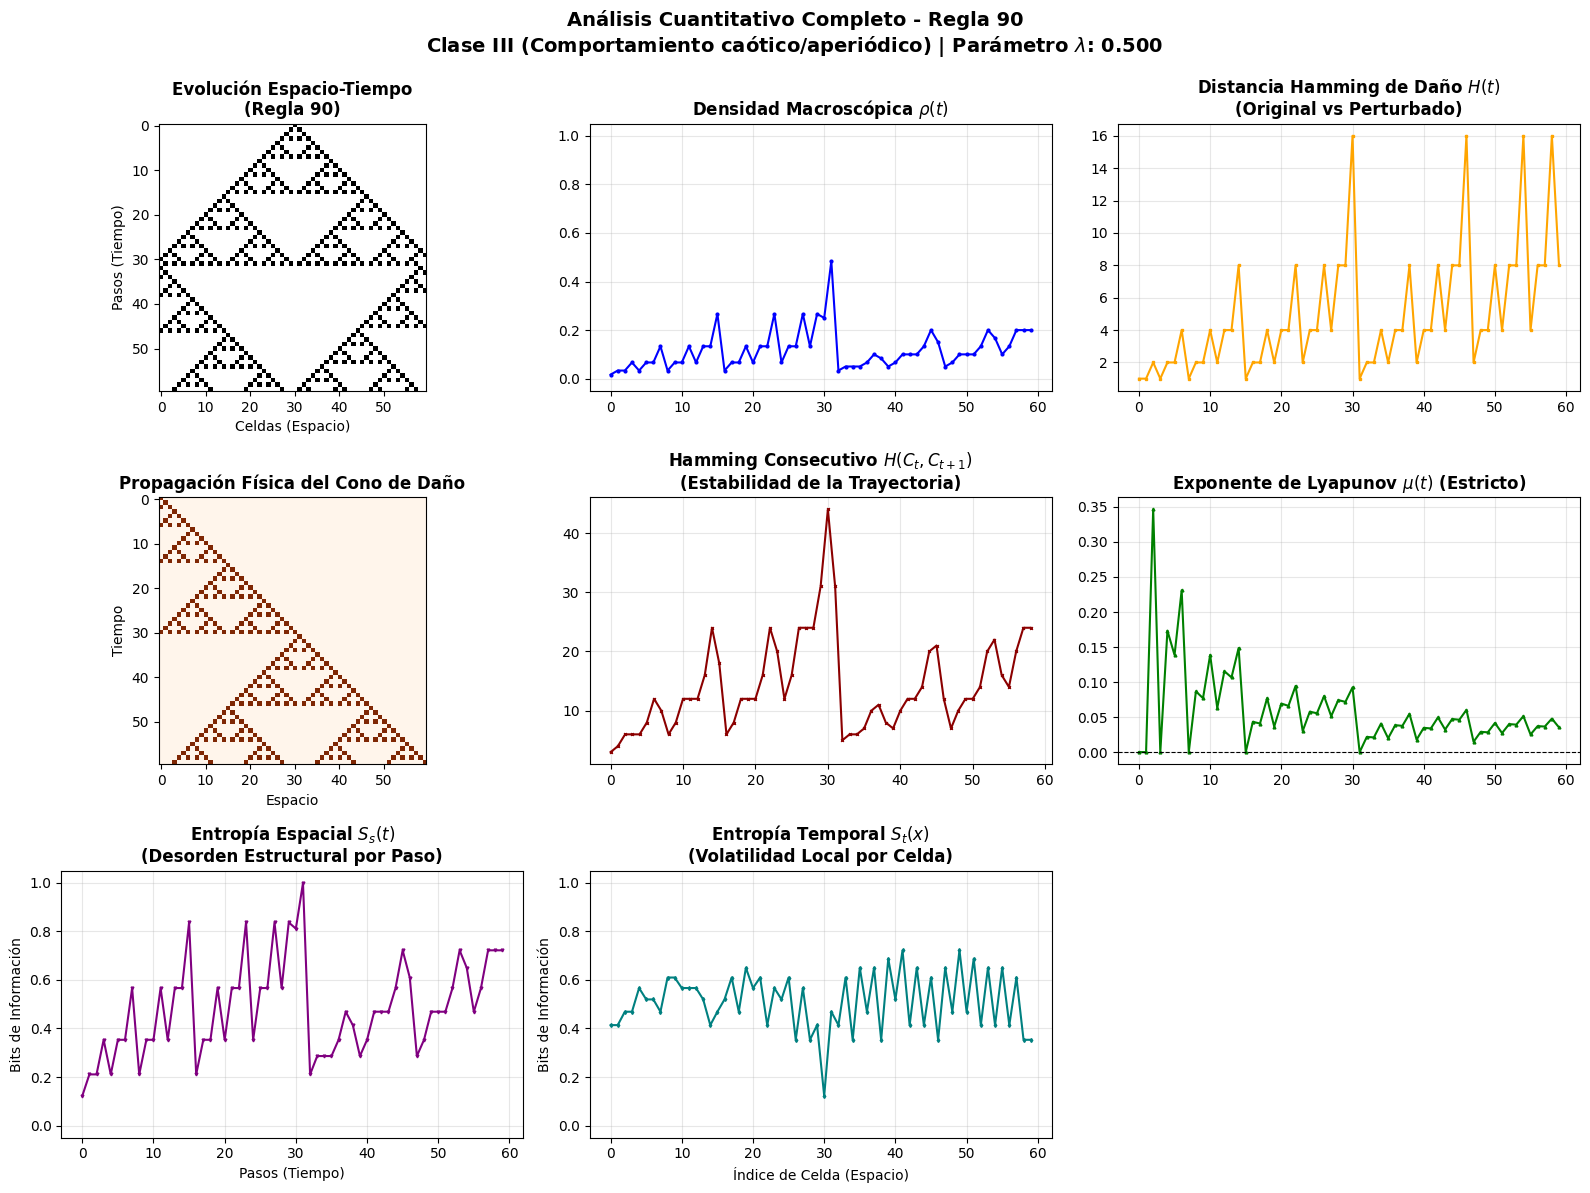

In [ ]:
# =========================================================================
# SIMULADOR DE MÉTRICAS CUANTITATIVAS (1D) - EDICIÓN COMPLETA CON ENTROPÍAS
# =========================================================================

import cellpylib as cpl
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DICCIONARIO COMPLETO DE REGLAS (WOLFRAM) ---
DICCIONARIO_COMPLETO_REGLAS = {
    "Clase I (Evolución hacia estado homogéneo)": [
        0, 8, 32, 40, 64, 72, 96, 104, 128, 136, 160, 168, 192, 200, 224, 232,
        4, 12, 36, 44, 68, 76, 100, 108, 132, 140, 164, 172, 196, 204, 228, 236,
        250, 252, 254, 255
    ],
    "Clase II (Estructuras periódicas o estables)": [
        1, 2, 3, 5, 6, 7, 9, 10, 11, 13, 14, 15, 16, 17, 19, 21, 23, 24, 25, 26, 27, 28, 29,
        33, 34, 35, 37, 38, 39, 41, 42, 43, 46, 47, 50, 51, 52, 53, 55, 56, 57, 58, 59, 61, 62, 63,
        65, 66, 67, 69, 70, 71, 73, 74, 75, 77, 78, 79, 80, 81, 82, 83, 84, 85, 87, 88, 89, 91, 92,
        93, 94, 95, 97, 98, 99, 101, 102, 103, 107, 111, 112, 113, 114, 115, 116, 117, 118, 119,
        121, 123, 125, 127, 130, 131, 133, 134, 135, 138, 139, 141, 142, 143, 144, 145, 148, 149,
        152, 153, 154, 155, 156, 157, 158, 159, 162, 163, 165, 166, 167, 170, 171, 173, 174, 175,
        176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 194, 197,
        198, 199, 201, 202, 203, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217,
        218, 219, 220, 221, 222, 223, 226, 227, 229, 230, 231, 233, 234, 235, 237, 238, 239, 240,
        241, 242, 243, 244, 245, 246, 247, 248, 249, 251, 253
    ],
    "Clase III (Comportamiento caótico/aperiódico)": [
        18, 22, 30, 45, 60, 90, 105, 122, 126, 146, 150, 129, 161, 169, 151, 225
    ],
    "Clase IV (Estructuras complejas/Gliders)": [
        54, 110, 137, 147, 193, 204
    ]
}

def determinar_clase(regla):
    for nombre_clase, lista_reglas in DICCIONARIO_COMPLETO_REGLAS.items():
        if regla in lista_reglas: return nombre_clase
    return "Clase no indexada"

# --- 2. MÉTODOS MATEMÁTICOS DE REQUERIMIENTOS ---
def calcular_lambda_langton(regla, radio):
    num_vecinos = 2 * radio + 1
    total_combinaciones = 2**num_vecinos
    regla_bin = [int(x) for x in np.binary_repr(regla, width=total_combinaciones)]
    return sum(regla_bin) / total_combinaciones

def calcular_distancia_hamming(c1, c2):
    return np.sum(c1 != c2)

def calcular_entropia_shannon(vector):
    """Calcula la entropía de Shannon (base 2) para un arreglo unidimensional."""
    if len(vector) == 0:
        return 0.0
    _, conteos = np.unique(vector, return_counts=True)
    probabilidades = conteos / len(vector)
    # Filtro para evitar el cálculo de log2(0) que arroja NaN
    probabilidades = probabilidades[probabilidades > 0]
    return -np.sum(probabilidades * np.log2(probabilidades))

# Función puente para controlar las fronteras manualmente dentro de CellPyLib
def aplicar_regla_con_frontera(n, c, t, regla_num, radio, tipo_borde, total_celdas):
    n_modificado = np.array(n)

    if tipo_borde == 'fixed':
        for i in range(len(n_modificado)):
            pos_absoluta = c + (i - radio)
            if pos_absoluta < 0 or pos_absoluta >= total_celdas:
                n_modificado[i] = 0  # Celda virtual fuera del límite = muerta (0)

    return cpl.nks_rule(n_modificado, regla_num)

# --- 3. MENÚ INTERACTIVO DE CONFIGURACIÓN ---
print("="*60)
print("   MEDIDAS CUANTITATIVAS - INVESTIGACIÓN Y CÁLCULO (1D)")
print("="*60)

radio_r = int(input("1. Radio de vecindario r (Wolfram clásico r=1): "))
regla_usuario = int(input("2. Número de regla (0-255): "))

print("\n3. Tipo de condición de frontera (Bordes):")
print("   [1] Cíclico / Periódico")
print("   [2] Límite Fijo / Muerto")
opcion_borde = int(input("   Selecciona (1 o 2): "))
borde = 'periodic' if opcion_borde == 1 else 'fixed'

print("\n4. Configuración de Estado Inicial:")
print("   [1] Inicialización Aleatoria")
print("   [2] Celda Única Central Activa")
opcion_init = int(input("   Selecciona (1 o 2): "))

CELDAS, PASOS = 60, 60

if opcion_init == 1:
    init_original = np.random.randint(2, size=(1, CELDAS))
else:
    init_original = np.zeros((1, CELDAS), dtype=int)
    init_original[0, CELDAS // 2] = 1

# Copia perturbada con exactamente 1 bit de diferencia en la celda 0 (d_0 = 1)
init_perturbado = init_original.copy()
init_perturbado[0, 0] = 1 - init_original[0, 0]

# --- 4. EVOLUCIÓN EN PARALELO DE LAS DOS TRAYECTORIAS ---
evolucion_orig = cpl.evolve(init_original, timesteps=PASOS, r=radio_r,
                            apply_rule=lambda n, c, t: aplicar_regla_con_frontera(n, c, t, regla_usuario, radio_r, borde, CELDAS))

evolucion_pert = cpl.evolve(init_perturbado, timesteps=PASOS, r=radio_r,
                            apply_rule=lambda n, c, t: aplicar_regla_con_frontera(n, c, t, regla_usuario, radio_r, borde, CELDAS))

# --- 5. ANÁLISIS Y PROCESAMIENTO DE MÉTRICAS ---
clase_txt = determinar_clase(regla_usuario)
param_lambda = calcular_lambda_langton(regla_usuario, radio_r)

densidades = []
distancias_hamming_dano = []
distancias_hamming_consecutivas = []
lyapunov_valores_reales = []
lyapunov_para_grafico = []
entropias_espaciales = []

for t in range(PASOS):
    fila_orig = evolucion_orig[t]
    fila_pert = evolucion_pert[t]

    densidades.append(np.mean(fila_orig))

    # Cálculo de Entropía Espacial S_s(t) para la trayectoria original
    entropias_espaciales.append(calcular_entropia_shannon(fila_orig))

    # Distancia de Hamming de Daño H(t)
    h_dano = calcular_distancia_hamming(fila_orig, fila_pert)
    distancias_hamming_dano.append(h_dano)

    # Distancia de Hamming Consecutiva Temporal H(C_t, C_t+1)
    if t < PASOS - 1:
        h_consec = calcular_distancia_hamming(evolucion_orig[t], evolucion_orig[t+1])
        distancias_hamming_consecutivas.append(h_consec)

    # Exponente de Lyapunov L(t) = (1/t) * ln(H(t))
    if t == 0:
        lyapunov_valores_reales.append(0.0)
        lyapunov_para_grafico.append(0.0)
    else:
        if h_dano > 0:
            val_lyap = (1.0 / t) * np.log(h_dano)
            lyapunov_valores_reales.append(val_lyap)
            lyapunov_para_grafico.append(val_lyap)
        else:
            lyapunov_valores_reales.append(-np.inf)
            lyapunov_para_grafico.append(-2.5)

# Cálculo de Entropía Temporal S_t(x) por cada columna (celda) a lo largo del tiempo
entropias_temporales = []
for x in range(CELDAS):
    columna_celda = evolucion_orig[:, x]
    entropias_temporales.append(calcular_entropia_shannon(columna_celda))

# --- 6. DESPLIEGUE VISUAL COMPARATIVO MATRIZ (3x3) ---
fig, axs = plt.subplots(3, 3, figsize=(16, 12))

# Filas 1 y 2: Métricas previas
axs[0, 0].imshow(evolucion_orig, cmap="binary", interpolation="nearest")
axs[0, 0].set_title(f"Evolución Espacio-Tiempo\n(Regla {regla_usuario})", fontweight="bold")
axs[0, 0].set_xlabel("Celdas (Espacio)")
axs[0, 0].set_ylabel("Pasos (Tiempo)")

axs[0, 1].plot(densidades, color="blue", marker="o", markersize=2)
axs[0, 1].set_title("Densidad Macroscópica $\\rho(t)$", fontweight="bold")
axs[0, 1].set_ylim(-0.05, 1.05)
axs[0, 1].grid(True, alpha=0.3)

axs[0, 2].plot(distancias_hamming_dano, color="orange", marker="s", markersize=2)
axs[0, 2].set_title("Distancia Hamming de Daño $H(t)$\n(Original vs Perturbado)", fontweight="bold")
axs[0, 2].grid(True, alpha=0.3)

mapa_dano = np.abs(evolucion_orig - evolucion_pert)
axs[1, 0].imshow(mapa_dano, cmap="Oranges", interpolation="nearest")
axs[1, 0].set_title("Propagación Física del Cono de Daño", fontweight="bold")
axs[1, 0].set_xlabel("Espacio")
axs[1, 0].set_ylabel("Tiempo")

axs[1, 1].plot(distancias_hamming_consecutivas, color="darkred", marker="x", markersize=2)
axs[1, 1].set_title("Hamming Consecutivo $H(C_t, C_{t+1})$\n(Estabilidad de la Trayectoria)", fontweight="bold")
axs[1, 1].grid(True, alpha=0.3)

axs[1, 2].plot(lyapunov_para_grafico, color="green", marker="^", markersize=2)
axs[1, 2].set_title("Exponente de Lyapunov $\\mu(t)$ (Estricto)", fontweight="bold")
axs[1, 2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[1, 2].grid(True, alpha=0.3)
if -2.5 in lyapunov_para_grafico:
    axs[1, 2].set_ylabel("Nota: -2.5 representa $-\\infty$ (Extinción)")

# Fila 3: Nuevas Métricas Incorporadas
# 7. Entropía Espacial a lo largo del Tiempo
axs[2, 0].plot(entropias_espaciales, color="purple", marker="v", markersize=2)
axs[2, 0].set_title("Entropía Espacial $S_s(t)$\n(Desorden Estructural por Paso)", fontweight="bold")
axs[2, 0].set_xlabel("Pasos (Tiempo)")
axs[2, 0].set_ylabel("Bits de Información")
axs[2, 0].set_ylim(-0.05, 1.05)
axs[2, 0].grid(True, alpha=0.3)

# 8. Entropía Temporal a lo largo del Espacio
axs[2, 1].plot(range(CELDAS), entropias_temporales, color="teal", marker="d", markersize=2)
axs[2, 1].set_title("Entropía Temporal $S_t(x)$\n(Volatilidad Local por Celda)", fontweight="bold")
axs[2, 1].set_xlabel("Índice de Celda (Espacio)")
axs[2, 1].set_ylabel("Bits de Información")
axs[2, 1].set_ylim(-0.05, 1.05)
axs[2, 1].grid(True, alpha=0.3)

# 9. Ajuste Estético: Apagar el último recuadro de la cuadrícula
axs[2, 2].axis('off')

plt.suptitle(f"Análisis Cuantitativo Completo - Regla {regla_usuario}\n{clase_txt} | Parámetro $\\lambda$: {param_lambda:.3f}", fontsize=14, fontweight="bold", y=0.99)
plt.tight_layout()

# --- 7. TABLA ESTADÍSTICA DE RESULTADOS EXTENDIDA ---
print("\n" + "="*50)
print("    MÉTRICAS ESTADÍSTICAS FINALES OBTENIDAS")
print("="*50)
print(f"Clasificación Formal        : {clase_txt}")
print(f"Parámetro λ de Langton      : {param_lambda:.4f}")
print(f"Densidad Media              : {np.mean(densidades):.4f}")
print(f"Entropía Espacial Media <Ss>: {np.mean(entropias_espaciales):.4f} bits")
print(f"Entropía Temporal Media <St>: {np.mean(entropias_temporales):.4f} bits")
print(f"Dist. Hamming Temporal Media: {np.mean(distancias_hamming_consecutivas):.4f} celdas/paso")

lyap_final = lyapunov_valores_reales[-1]
if lyap_final == -np.inf:
    print(f"Lyapunov Final (t={PASOS-1})       : -infinito (El daño se absorbió por completo)")
else:
    print(f"Lyapunov Final (t={PASOS-1})       : {lyap_final:.4f}")
print("="*50)

plt.show()

 Desglose Estructural del Código

 1. Diccionario de Clasificación y Mapeo (DICCIONARIO_COMPLETO_REGLAS)

 Qué hace: Es una base de datos estática indexada. Almacena las 256 reglas posibles de Wolfram agrupadas estrictamente según sus 4 clases de comportamiento macroscópico.

 Función asociada (determinar_clase): Recibe el número de regla que ingresa el usuario, barre el diccionario usando un bucle for y devuelve un string con el nombre de la clase formal. Si la regla no está (por ejemplo, si pruebas una regla con un radio mayor que 1), devuelve "Clase no indexada".

 2. Módulos de Métricas Matemáticas (Funciones calcular_...)

 Aquí se procesa la física analítica del sistema de forma vectorizada gracias a NumPy:

 calcular_lambda_langton: Convierte el número entero de la regla a su representación binaria pura según el tamaño de su vecindario ($2^{2r+1}$). Cuenta cuántos unos (1) tiene esa regla y los divide entre el total de combinaciones. Mide qué tan "activa" es la regla antes de correrla.

 calcular_distancia_hamming: Compara dos vectores elemento por elemento usando el operador lógico de desigualdad !=. Al aplicar np.sum(), cuenta cuántas celdas difieren entre ambos estados. Es el núcleo analítico para medir la propagación del daño.

 calcular_entropia_shannon: Calcula el desorden de información ($S = -\sum p_i \log_2 p_i$).Detalle técnico clave: Usa np.unique(..., return_counts=True) para extraer las frecuencias de ceros y unos. Incluye una máscara de filtrado (probabilidades > 0) para evitar que el código intente calcular $\log_2(0)$, lo que rompería el programa arrojando un error de tipo NaN (Not a Number).

 3. Inyección de Condiciones de Frontera (aplicar_regla_con_frontera)

 Qué hace: Actúa como un puente de control (wrapper) entre tu código y la librería CellPyLib.

 Por qué es necesaria: Por defecto, CellPyLib solo entiende fronteras cíclicas (periódicas). Esta estructura intercepta el vecindario de celdas (n) justo antes de evaluar la regla de Wolfram (cpl.nks_rule). Si el usuario seleccionó "Límite Fijo", la función calcula la posición absoluta de los vecinos y, si detecta que están fuera de la matriz ($<0$ o $\ge \text{CELDAS}$), fuerza recursivamente a que esas celdas virtuales valgan 0 (borde muerto), permitiendo simular paredes reflectoras de información.

 4. Inicialización de Estados y Sembrado de CaosQué hace: Prepara el experimento termodinámico. Define el tamaño de la matriz ($60 \times 60$) y genera dos condiciones iniciales distintas:

 init_original: La trayectoria de control (puede ser un tablero aleatorio o una sola celda central activa).init_perturbado: Una copia exacta de la original, pero aplicando una perturbación controlada de un solo bit en la primera celda (init_perturbado[0, 0] = 1 - init_original[0, 0]). Esto planta la semilla para evaluar el Efecto Mariposa.5. Motor de Evolución en Paralelo (cpl.evolve

 )Qué hace: Dispara el cómputo pesado. Corre de forma síncrona dos simulaciones independientes en la memoria RAM utilizando las configuraciones iniciales previamente declaradas. Al finalizar, genera dos tensores bidimensionales (evolucion_orig y evolucion_pert) de tamaño $\text{PASOS} \times \text{CELDAS}$ que contienen la historia completa de los autómatas.

 6. Bucle de Procesamiento Temporal y Espacial (Loop for t in range(PASOS))

 Qué hace: Es el recolector de datos. Recorre fila por fila (paso a paso en el tiempo) las matrices de evolución para extraer las variables dinámicas:Extrae la densidad media de celdas vivas en cada instante $t$.

 Calcula la Entropía Espacial de cada fila.Mide la distancia de Hamming entre la fila original y la perturbada en el tiempo $t$.

 Calcula el Exponente de Lyapunov dividiendo el logaritmo de la distancia de Hamming entre el tiempo transcurrido ($\frac{1}{t} \ln H(t)$). Si el daño se extingue ($H(t) = 0$), el código intercepta la indeterminación del logaritmo natural y asigna un valor controlado de $-2.5$ para que la gráfica no se rompa y marque la "extinción" del caos.

 Segunda fase (Bucle Espacial): Al salir del bucle temporal, ejecuta un bucle a lo largo del espacio (for x in range(CELDAS)) para extraer las columnas completas y calcular la Entropía Temporal de cada celda a través del tiempo.

 7. Matriz Gráfica 3x3 (plt.subplots)

 Qué hace: Estructura de visualización de datos. Define un lienzo de subgráficos ordenados perfectamente en una cuadrícula de 3 filas y 3 columnas:

 Fila 1: Morfología macroscópica (Espacio-tiempo, densidad fluctuante y evolución de la distancia de daño).

 Fila 2: Dinámica del cono de daño (gráfica diferencial), estabilidad cinética sucesiva y convergencia del exponente de Lyapunov.

 Fila 3: Los nuevos perfiles incorporados (Entropía Espacial a la izquierda, Entropía Temporal al centro). El recuadro de la esquina inferior derecha se apaga explícitamente con axs[2, 2].axis('off') para mantener una estética limpia y asimétrica.

 8. Despliegue Estadístico por Consola

 Qué hace: Es el cierre del programa. Toma todos los arreglos dinámicos calculados en los bucles anteriores, les extrae la media aritmética global (np.mean) e imprime en la terminal una tabla limpia con bordes de caracteres ASCII que resume numéricamente el comportamiento termodinámico final del autómata simulado.


     ACTIVIDAD 2: SIMULADOR DE MÉTRICAS CUANTITATIVAS (2D)
     REGLA: EL JUEGO DE LA VIDA DE CONWAY (CLASE IV)
Evolucionando sistemas bidimensionales en paralelo...
Procesando estadísticas y renderizando gráficos...

      TABLA DE RESULTADOS CUANTITATIVOS 2D
Regla analizada       : Juego de la Vida (Conway)
Parámetro λ de Langton: 0.2734 (Valor crítico NKS)
Densidad Promedio     : 0.2282
Entropía Espacial Med : 0.7562
Entropía Temporal Med : 0.6965
Lyapunov Final (t=29) : 0.1854


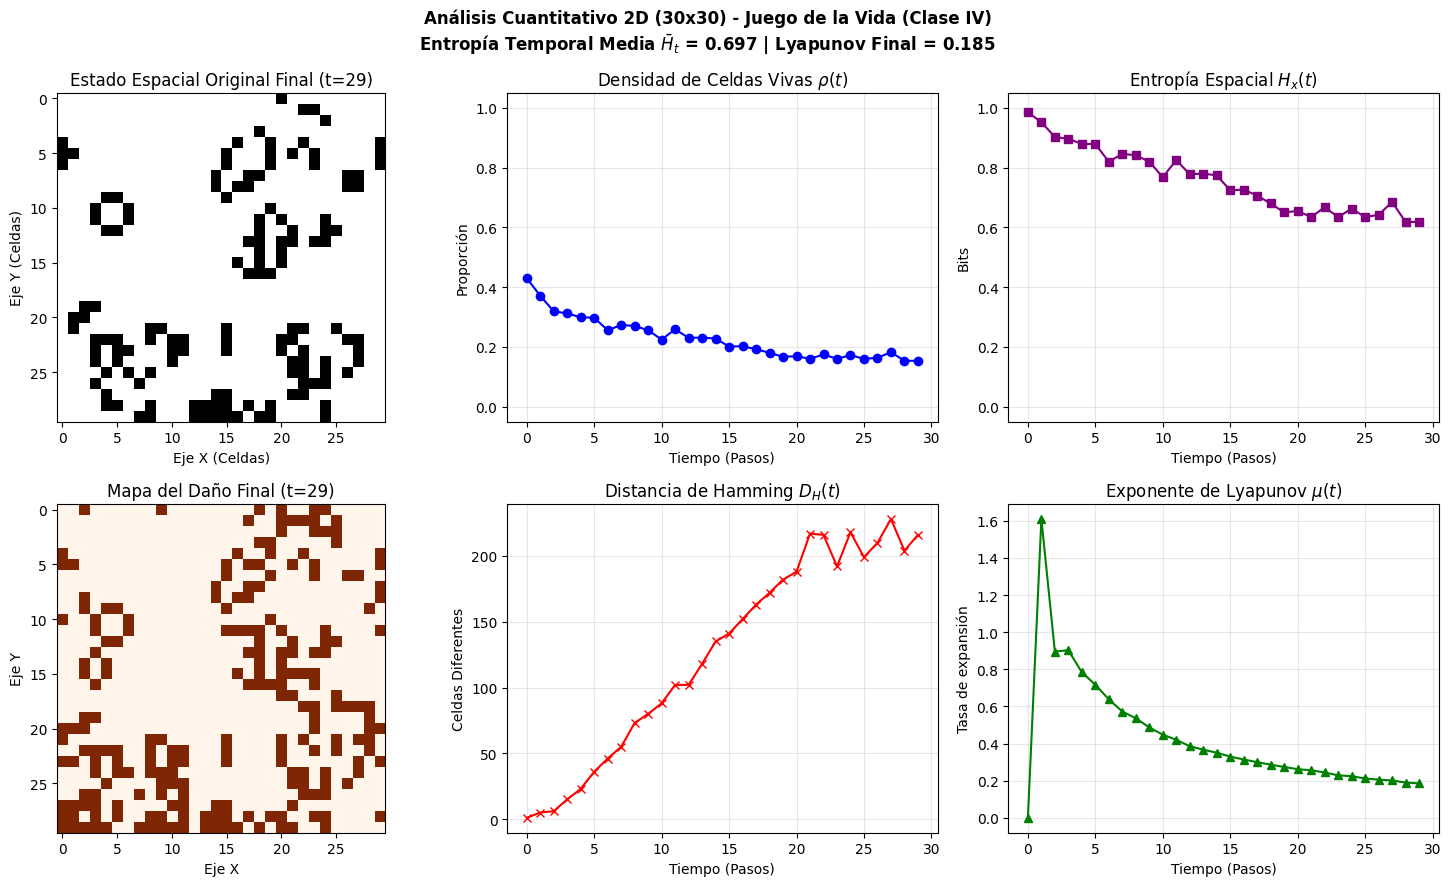

In [ ]:
import cellpylib as cpl
import numpy as np
import matplotlib.pyplot as plt

def calcular_entropia_shannon_2d(matriz_o_vector):
    """Calcula la entropía de Shannon para un conjunto de estados binarios."""
    total = matriz_o_vector.size
    if total == 0:
        return 0.0
    unos = np.sum(matriz_o_vector)
    ceros = total - unos
    p1 = unos / total
    p0 = ceros / total

    entropia = 0.0
    for p in [p0, p1]:
        if p > 0:
            entropia -= p * np.log2(p)
    return entropia

# --- CONFIGURACIÓN DEL ESPACIO Y TIEMPO (30x30x30) ---
L = 30       # Filas y columnas de la rejilla espacial
PASOS = 30   # Pasos de tiempo de la evolución

print("\n" + "="*60)
print("     ACTIVIDAD 2: SIMULADOR DE MÉTRICAS CUANTITATIVAS (2D)")
print("     REGLA: EL JUEGO DE LA VIDA DE CONWAY (CLASE IV)")
print("="*60)

# 1. Configuración de la condición inicial desordenada (Frontera Cíclica por defecto en cellpylib 2D)
init_original = np.random.choice([0, 1], size=(L, L), p=[1 - 0.4, 0.4]) # 40% de probabilidad de celdas vivas
init_original = init_original.reshape(1, L, L) # Reshape to (1, L, L) for cpl.evolve2d

# 2. Configuración del sistema perturbado (Invertimos exactamente la celda central para medir daño)
init_perturbado = init_original.copy()
centro_f, centro_c = L // 2, L // 2
# Adjust indexing for 3D array (1, L, L)
init_perturbado[0, centro_f, centro_c] = 1 if init_original[0, centro_f, centro_c] == 0 else 0

# 3. Evolución temporal de ambos sistemas usando las reglas del Juego de la Vida (Game of Life)
print("Evolucionando sistemas bidimensionales en paralelo...")
evolucion_orig = cpl.evolve2d(
    init_original, timesteps=PASOS,
    apply_rule=lambda n, c, t: cpl.game_of_life_rule(n, c, t)
)

evolucion_pert = cpl.evolve2d(
    init_perturbado, timesteps=PASOS,
    apply_rule=lambda n, c, t: cpl.game_of_life_rule(n, c, t)
)

# --- CÁLCULO DE LAS MÉTRICAS PASO A PASO ---
densidades = []
distancias_hamming = []
lyapunov_exponents = []
entropias_espaciales = []

for t in range(PASOS):
    plano_orig = evolucion_orig[t]
    plano_pert = evolucion_pert[t]

    # 1. Densidad de celdas vivas
    densidades.append(np.sum(plano_orig) / (L * L))

    # 2. Distancia de Hamming en 2D
    hamming = np.sum(np.abs(plano_orig - plano_pert))
    distancias_hamming.append(hamming)

    # 3. Exponente de Lyapunov discretizado (D_H(0) = 1)
    if t > 0 and hamming > 0:
        lyapunov = (1 / t) * np.log(hamming / 1)
    else:
        lyapunov = 0.0
    lyapunov_exponents.append(lyapunov)

    # 4. Entropía Espacial 2D
    entropias_espaciales.append(calcular_entropia_shannon_2d(plano_orig))

# 5. Entropía Temporal (Se calcula la evolución de cada coordenada a lo largo del tiempo)
entropias_temporales_celdas = []
for i in range(L):
    for j in range(L):
        # Extraemos el vector temporal de la celda (i, j)
        vector_temporal = evolucion_orig[:, i, j]
        entropias_temporales_celdas.append(calcular_entropia_shannon_2d(vector_temporal))
entropia_temporal_media = np.mean(entropias_temporales_celdas)

# --- GENERACIÓN DEL PANEL DE GRÁFICAS COMPARATIVAS 2D ---
print("Procesando estadísticas y renderizando gráficos...")
fig, axs = plt.subplots(2, 3, figsize=(15, 9))

# Gráfica 1: Estado Final del Sistema Original (t = final)
axs[0, 0].imshow(evolucion_orig[-1], cmap="binary", interpolation="nearest")
axs[0, 0].set_title(f"Estado Espacial Original Final (t={PASOS-1})")
axs[0, 0].set_xlabel("Eje X (Celdas)")
axs[0, 0].set_ylabel("Eje Y (Celdas)")

# Gráfica 2: Densidad Activa en el Tiempo
axs[0, 1].plot(densidades, color="blue", marker="o", linestyle="-")
axs[0, 1].set_title("Densidad de Celdas Vivas $\\rho(t)$")
axs[0, 1].set_xlabel("Tiempo (Pasos)")
axs[0, 1].set_ylabel("Proporción")
axs[0, 1].set_ylim(-0.05, 1.05)
axs[0, 1].grid(True, alpha=0.3)

# Gráfica 3: Entropía Espacial 2D en el Tiempo
axs[0, 2].plot(entropias_espaciales, color="purple", marker="s", linestyle="-")
axs[0, 2].set_title("Entropía Espacial $H_x(t)$")
axs[0, 2].set_xlabel("Tiempo (Pasos)")
axs[0, 2].set_ylabel("Bits")
axs[0, 2].set_ylim(-0.05, 1.05)
axs[0, 2].grid(True, alpha=0.3)

# Gráfica 4: Mapa Acumulado del Daño (Dónde difieren los dos sistemas al final)
mapa_daño_final = np.abs(evolucion_orig[-1] - evolucion_pert[-1])
axs[1, 0].imshow(mapa_daño_final, cmap="Oranges", interpolation="nearest")
axs[1, 0].set_title(f"Mapa del Daño Final (t={PASOS-1})")
axs[1, 0].set_xlabel("Eje X")
axs[1, 0].set_ylabel("Eje Y")

# Gráfica 5: Distancia de Hamming en el Tiempo
axs[1, 1].plot(distancias_hamming, color="red", marker="x", linestyle="-")
axs[1, 1].set_title("Distancia de Hamming $D_H(t)$")
axs[1, 1].set_xlabel("Tiempo (Pasos)")
axs[1, 1].set_ylabel("Celdas Diferentes")
axs[1, 1].grid(True, alpha=0.3)

# Gráfica 6: Exponente de Lyapunov en el Tiempo
axs[1, 2].plot(lyapunov_exponents, color="green", marker="^", linestyle="-")
axs[1, 2].set_title("Exponente de Lyapunov $\\mu(t)$")
axs[1, 2].set_xlabel("Tiempo (Pasos)")
axs[1, 2].set_ylabel("Tasa de expansión")
axs[1, 2].grid(True, alpha=0.3)

# --- IMPRESIÓN DE TABLA RESUMEN EN CONSOLA ---
print("\n" + "="*40)
print("      TABLA DE RESULTADOS CUANTITATIVOS 2D")
print("="*40)
print("Regla analizada       : Juego de la Vida (Conway)")
print("Parámetro λ de Langton: 0.2734 (Valor crítico NKS)")
print(f"Densidad Promedio     : {np.mean(densidades):.4f}")
print(f"Entropía Espacial Med : {np.mean(entropias_espaciales):.4f}")
print(f"Entropía Temporal Med : {entropia_temporal_media:.4f}")
print(f"Lyapunov Final (t=29) : {lyapunov_exponents[-1]:.4f}")
print("="*40)

plt.suptitle(f"Análisis Cuantitativo 2D ({L}x{L}) - Juego de la Vida (Clase IV)\nEntropía Temporal Media $\\bar{{H}}_t$ = {entropia_temporal_media:.3f} | Lyapunov Final = {lyapunov_exponents[-1]:.3f}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


--- Selecciona una imagen existente ---
[0] Nicolás_Maduro_2015_(cropped).jpg
[1] Subir una imagen nueva

Ingresa el número de tu elección: 1


Saving Captura de pantalla 2026-04-02 112802.png to Captura de pantalla 2026-04-02 112802.png


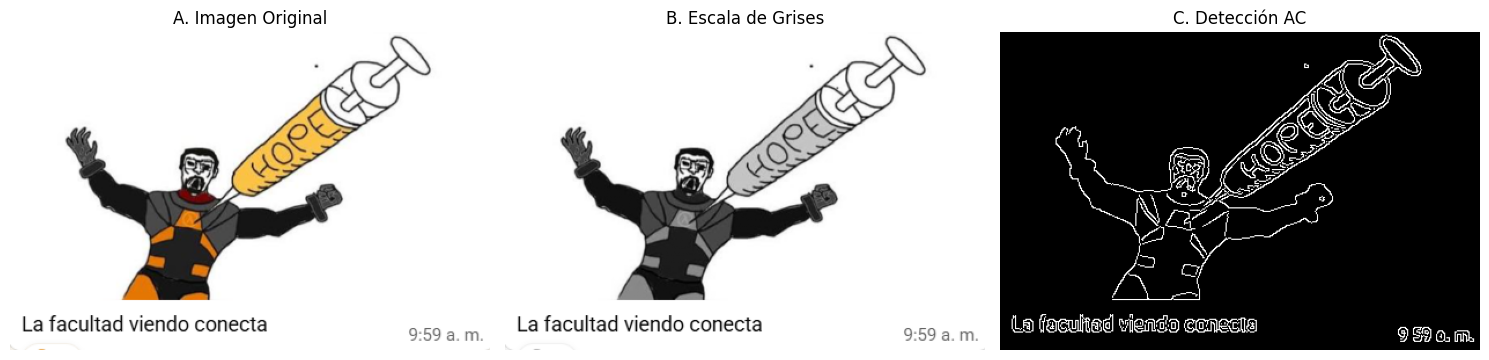

In [ ]:
import cellpylib as cpl
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from google.colab import files

# 1. REGLA ROBUSTA (Misma lógica, alta eficiencia)
class ReglaBordeRobusta(cpl.BaseRule):
    def __init__(self):
        super().__init__()

    def __call__(self, n, c, t):
        center = n[1][1]
        for i in range(3):
            for j in range(3):
                if n[i][j] != center:
                    return 1
        return 0

# 2. FUNCIÓN DE PROCESAMIENTO CON SELECTOR
def Procesar_Imagen_Seleccionada():
    # Listar imágenes en la carpeta actual
    archivos = [f for f in os.listdir('.') if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not archivos:
        print("No hay imágenes en la carpeta. Subiendo una nueva...")
        uploaded = files.upload()
        nombre_archivo = list(uploaded.keys())[0]
    else:
        print("\n--- Selecciona una imagen existente ---")
        for i, nombre in enumerate(archivos):
            print(f"[{i}] {nombre}")
        print(f"[{len(archivos)}] Subir una imagen nueva")

        seleccion = int(input("\nIngresa el número de tu elección: "))

        if seleccion == len(archivos):
            uploaded = files.upload()
            nombre_archivo = list(uploaded.keys())[0]
        else:
            nombre_archivo = archivos[seleccion]

    # --- Lógica de procesamiento (lo que ya funcionaba) ---
    img_cv2 = cv2.imread(nombre_archivo)
    # Check if image was loaded successfully
    if img_cv2 is None:
        print(f"Error: No se pudo cargar la imagen desde {nombre_archivo}")
        return

    imagen_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    edges_canny = cv2.Canny(blurred, 50, 150)
    matriz_binaria = (edges_canny > 0).astype(np.int32)

    espacio_inicial = np.array([matriz_binaria])
    mi_regla = ReglaBordeRobusta()
    # FIX: Use cpl.evolve2d for 2D cellular automata and remove 'r=1'
    evolucion = cpl.evolve2d(espacio_inicial, timesteps=1, apply_rule=mi_regla)

    # Visualización
    fig, ejes = plt.subplots(1, 3, figsize=(15, 5))
    ejes[0].imshow(imagen_rgb)
    ejes[0].set_title("A. Imagen Original")
    ejes[0].axis('off')

    ejes[1].imshow(gray, cmap='gray')
    ejes[1].set_title("B. Escala de Grises")
    ejes[1].axis('off')

    # FIX: When timesteps=1, the evolved state is at index 0
    ejes[2].imshow(evolucion[0], cmap='binary_r')
    ejes[2].set_title("C. Detección AC")
    ejes[2].axis('off')

    plt.tight_layout()
    plt.show()

# --- Ejecución ---
Procesar_Imagen_Seleccionada()

# **1. Transformación de RGB a Escala de Grises:**

Fotometría Colectiva

Cuando se carga la imagen con cv2.imread, el computador la interpreta como un campo vectorial de tres dimensiones por píxel:

$\mathbf{I}(x,y) = (R, G, B)$.

Para detectar bordes, no nos interesa el color (frecuencia de la luz), sino las variaciones espaciales de la radiancia o intensidad energética.

La función cv2.cvtColor(img_cv2, cv2.COLOR_BGR2GRAY) colapsa ese campo vectorial en un campo escalar unidimensional $Y(x,y)$ mediante una combinación lineal ponderada:

$$Y = 0.299R + 0.587G + 0.114B$$

¿Por qué esos coeficientes matemáticos tan específicos?

No son arbitrarios; provienen de la física de la visión humana y la curva de eficiencia luminosa fotópica ($V_\lambda$). Nuestras retinas tienen una densidad mucho mayor de conos sensibles a las longitudes de onda del verde y el rojo que a las del azul. El coeficiente del Verde ($0.587$) es el más alto porque el ojo humano es ópticamente más sensible a las diferencias de intensidad en esa región del espectro electromagnético.

# **2. El Filtro Gaussiano:**

La Ecuación de Difusión Térmica

La línea cv2.GaussianBlur(gray, (5, 5), 0) aplica una convolución espacial utilizando un núcleo (kernel) bidimensional basado en la distribución normal.

$$I_{\text{blurred}}(x,y) = I(x,y) * G(x,y;\sigma)$$

Donde la función gaussiana es:

$$G(x,y;\sigma) = \frac{1}{2\pi\sigma^2} \exp\left(-\frac{x^2+y^2}{2\sigma^2}\right)$$

En física, esto es exactamente equivalente a mapear la evolución temporal de un perfil de temperatura usando la Ecuación de Difusión de Calor (Segunda Ley de Fick):

$$\frac{\partial I}{\partial t} = D \nabla^2 I$$

La distribución gaussiana es la función de Green (la solución fundamental) de esta ecuación diferencial parcial. Aplicar un desenfoque gaussiano con un ancho $\sigma$ es físicamente idéntico a permitir que los niveles de gris de la imagen se "difundan" térmicamente hacia sus vecinos durante un tiempo finito $t \propto \sigma^2$.

Se utiliza para eliminar las fluctuaciones estadísticas de alta frecuencia (el ruido microscópico de la imagen), que se comportarían como falsas fuentes de energía endotérmica al calcular las derivadas.

# **3. Algoritmo de Canny:**

Campos de Gradiente y Singularidades

La función cv2.Canny(blurred, 50, 150) localiza dónde el campo escalar experimenta las variaciones más violentas. Matemáticamente, calcula el vector gradiente de la intensidad del espacio reflectivo:

$$\nabla I = \left( \frac{\partial I}{\partial x}, \frac{\partial I}{\partial y} \right)$$

El algoritmo de Canny realiza tres pasos físicos cruciales:

Magnitud y Dirección: Encuentra la fuerza del campo de fuerzas vectorial $\|\nabla I\| = \sqrt{(\frac{\partial I}{\partial x})^2 + (\frac{\partial I}{\partial y})^2}$ y la dirección normal al borde.

Supresión de No-Máximos: Reduce el espesor de las líneas buscando los máximos locales a lo largo de la dirección del gradiente.

Histéresis (Umbralización): Utiliza dos límites (50 y 150). Si la magnitud del gradiente supera 150, se acepta como borde real de forma determinista. Si está por debajo de 50, se desecha. Si está en el medio, solo se acepta si está conectado físicamente a un píxel que ya es un borde fuerte. Esto es análogo a los procesos de nucleación y transiciones de fase por vecindad en termodinámica.Al final, transformas el resultado en una matriz booleana discreta (matriz_binaria), donde un 1 representa la presencia de una frontera geométrica y un 0 representa el vacío o la homogeneidad espacial.

# **4. El Autómata Celular 2D:**

Dinámica de Campos Locales

Aquí entramos en el corazón del código con cellpylib. Al pasar de un espacio 1D a un espacio 2D, el autómata celular opera sobre una red cristalina bidimensional $\mathcal{L}$ regida por interacciones de corto alcance.

El Vecindario de MooreTu clase ReglaBordeRobusta inspecciona una matriz de $3 \times 3$ elementos alrededor de cada celda central $c$. En física de sistemas complejos, este conjunto de 8 vecinos adyacentes se denomina Vecindario de Moore.

Si analizamos esta lógica desde la perspectiva de la física de superficies y topología discreta, la regla ejecuta lo siguiente:

Evaluación de la Isotropía: El código extrae el estado de la celda central (n[1][1]) y barre sus alrededores.

Ruptura de Simetría Local: Si al menos uno de los vecinos tiene un estado diferente al centro (n[i][j] != center), la simetría local se rompe. Esto significa matemáticamente que un contorno o una interfaz de fase pasa exactamente a través de ese vecindario microscópico de 3×3. Como consecuencia, el autómata asigna un 1 a la celda en el siguiente paso temporal (t+1).

Condición de Homogeneidad: Si todos los vecinos son idénticos al centro (ya sea que todo el vecindario sea un bloque sólido de 1s o un vacío absoluto de 0s), el gradiente discreto es nulo. No hay frontera, por lo que la celda se apaga (return 0).

Una analogía con el Modelo de Ising

Esta regla funciona de manera muy similar a un cálculo de energía de interfaz en un sistema magnético como el Modelo de Ising. El autómata celular penaliza la uniformidad y premia las zonas de tensión interfacial (donde los espines o estados cambian bruscamente).

Al ejecutar el autómata con un solo paso de tiempo (timesteps=1), lo que estás haciendo no es buscar un estado estacionario termodinámico a largo plazo, sino usar el autómata como un filtro morfológico laplaciano no lineal de alta velocidad para limpiar, conectar e iluminar los bordes remanentes que el algoritmo de Canny dejó inconclusos.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import io
import os
import imageio.v2 as imageio
from IPython.display import display, Image, clear_output
from matplotlib.colors import ListedColormap

class ISAACDynamicCombatSimulation:
    def __init__(self, grid_size=40, num_blue=45, num_red=45,
                 sensor_range=12.0, combat_range=2.5, p_kill=0.35, p_explore=0.15,
                 w_goal_blue=1.0, w_enemy_blue=4.5,
                 w_goal_red=1.0, w_enemy_red=4.5, con_obstaculos=False):

        self.size = grid_size
        self.grid = np.zeros((self.size, self.size), dtype=int)

        # Metas estratégicas de infiltración
        self.blue_goal = np.array([self.size - 1, self.size - 1])
        self.red_goal = np.array([0, 0])

        # Parámetros del modelo de combate globales
        self.sensor_range = sensor_range
        self.combat_range = combat_range
        self.p_kill = p_kill
        self.p_explore = p_explore

        # Pesos del potencial táctico Z (Diferenciados por bando)
        self.w_goal_blue = w_goal_blue
        self.w_enemy_blue = w_enemy_blue
        self.w_goal_red = w_goal_red
        self.w_enemy_red = w_enemy_red

        # Generación opcional de obstáculos estructurales (Trincheras)
        if con_obstaculos:
            self._generar_obstaculos()

        self.agents = []
        self._initialize_agents(num_blue, num_red)

    def _generar_obstaculos(self):
        # Generar bloques de muros en la zona central divisoria
        num_bloques = int(self.size * 1.8)
        for _ in range(num_bloques):
            x = random.randint(self.size // 4, 3 * self.size // 4)
            y = random.randint(self.size // 4, 3 * self.size // 4)
            self.grid[x, y] = 3  # Código 3 reservado para obstáculos físicos

    def _initialize_agents(self, num_blue, num_red):
        # Batallón Azul (1) - Cuadrante superior izquierdo
        for _ in range(num_blue):
            while True:
                x, y = random.randint(0, self.size//6), random.randint(0, self.size//6)
                if self.grid[x, y] == 0:
                    self.grid[x, y] = 1
                    self.agents.append({'type': 'blue', 'pos': np.array([x, y]), 'alive': True})
                    break
        # Batallón Rojo (2) - Cuadrante inferior derecho
        for _ in range(num_red):
            while True:
                x, y = random.randint(5*self.size//6, self.size-1), random.randint(5*self.size//6, self.size-1)
                if self.grid[x, y] == 0:
                    self.grid[x, y] = 2
                    self.agents.append({'type': 'red', 'pos': np.array([x, y]), 'alive': True})
                    break

    def _get_valid_moves(self, pos):
        moves = []
        x, y = pos
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx, ny = x + dx, y + dy
                if 0 <= nx < self.size and 0 <= ny < self.size:
                    # El agente solo puede moverse si el terreno está vacío (0) o si decide quedarse quieto
                    if self.grid[nx, ny] == 0 or (dx == 0 and dy == 0):
                        moves.append(np.array([nx, ny]))
        return moves

    def _evaluate_move(self, agent, candidate_pos):
        # Asignación de pesos y metas según la naturaleza del bando
        if agent['type'] == 'blue':
            goal = self.blue_goal
            w_goal = self.w_goal_blue
            w_enemy = self.w_enemy_blue
        else:
            goal = self.red_goal
            w_goal = self.w_goal_red
            w_enemy = self.w_enemy_red

        d_goal = np.linalg.norm(candidate_pos - goal)

        enemy_distances = []
        for other in self.agents:
            if not other['alive'] or other['type'] == agent['type']:
                continue
            dist = np.linalg.norm(candidate_pos - other['pos'])
            if dist <= self.sensor_range:
                enemy_distances.append(dist)

        # Ecuación de Campo de Potencial Táctico Z
        z = w_goal * d_goal
        if enemy_distances:
            z += w_enemy * np.min(enemy_distances)

        return z

    def step(self):
        # 1. FASE DE MOVIMIENTO ASÍNCRONO
        random.shuffle(self.agents)
        for agent in self.agents:
            if not agent['alive']: continue

            valid_moves = self._get_valid_moves(agent['pos'])
            if not valid_moves: continue

            if random.random() < self.p_explore:
                best_move = random.choice(valid_moves)
            else:
                best_move = agent['pos']
                best_z = float('inf')
                for move in valid_moves:
                    z = self._evaluate_move(agent, move)
                    if z < best_z:
                        best_z = z
                        best_move = move

            # Limpiar celda vieja si se mueve (y no es un obstáculo camuflado)
            if self.grid[agent['pos'][0], agent['pos'][1]] in [1, 2]:
                self.grid[agent['pos'][0], agent['pos'][1]] = 0

            agent['pos'] = best_move
            self.grid[agent['pos'][0], agent['pos'][1]] = 1 if agent['type'] == 'blue' else 2

        # 2. FASE DE COMBATE SIMULTÁNEO
        dead_this_step = set()
        for i, agent in enumerate(self.agents):
            if not agent['alive']: continue

            closest_enemy_idx = None
            min_dist = float('inf')

            for j, other in enumerate(self.agents):
                if not other['alive'] or other['type'] == agent['type']:
                    continue
                dist = np.linalg.norm(agent['pos'] - other['pos'])
                if dist <= self.combat_range and dist < min_dist:
                    min_dist = dist
                    closest_enemy_idx = j

            if closest_enemy_idx is not None:
                if random.random() < self.p_kill:
                    dead_this_step.add(closest_enemy_idx)

        # 3. APLICACIÓN DE BAJAS
        for idx in dead_this_step:
            target = self.agents[idx]
            if target['alive']:
                self.grid[target['pos'][0], target['pos'][1]] = 0
                target['alive'] = False


def lanzar_menu_e_iniciar_simulacion():
    print("="*60)
    print("      CONFIGURADOR INTERACTIVO - MODELO DE COMBATE ISAAC")
    print("="*60)

    # 1. Entorno y Tiempos
    grid_size = int(input("Tamaño del mapa (Recomendado 40): ") or 40)
    max_steps = int(input("Número máximo de pasos/turnos (Recomendado 120): ") or 120)

    # 2. Magnitud de los Ejércitos
    num_blue = int(input("\nNúmero de soldados AZULES (Controladores): ") or 45)
    num_red = int(input("Número de soldados ROJOS (Atacantes): ") or 45)

    # 3. Constantes Microscópicas
    sensor_range = float(input("\nRango del radar/sensor de los agentes (Recomendado 12.0): ") or 12.0)
    combat_range = float(input("Rango de fuego/combate (Cuerpo a cuerpo=1.0 | Rango=2.5): ") or 2.5)
    p_kill = float(input("Letalidad del disparo p_kill (0.0 a 1.0 | Recomendado 0.35): ") or 0.35)
    p_explore = float(input("Factor de ruido/caos p_explore (0.0 a 1.0 | Recomendado 0.15): ") or 0.15)

    # 4. Filosofía Táctica del Bando Azul
    print("\n--- PERFIL TÁCTICO: EJÉRCITO AZUL ---")
    w_goal_blue = float(input("Atracción hacia su Meta (Recomendado 1.0): ") or 1.0)
    w_enemy_blue = float(input("Atracción hacia el Enemigo (Agresivo > 0 | Evasivo < 0): ") or 4.5)

    # 5. Filosofía Táctica del Bando Rojo
    print("\n--- PERFIL TÁCTICO: EJÉRCITO ROJO ---")
    w_goal_red = float(input("Atracción hacia su Meta (Recomendado 1.0): ") or 1.0)
    w_enemy_red = float(input("Atracción hacia el Enemigo (Agresivo > 0 | Evasivo < 0): ") or 4.5)

    # 6. Entorno Físico
    obst_inp = input("\n¿Añadir trincheras/obstáculos en el centro del campo? (S/N): ").strip().lower()
    con_obstaculos = True if obst_inp == 's' else False

    # --- INICIO DEL PROCESAMIENTO ---
    clear_output()
    print("[1/3] Construyendo campo de batalla y posicionando batallones...")

    sim = ISAACDynamicCombatSimulation(
        grid_size=grid_size, num_blue=num_blue, num_red=num_red,
        sensor_range=sensor_range, combat_range=combat_range, p_kill=p_kill, p_explore=p_explore,
        w_goal_blue=w_goal_blue, w_enemy_blue=w_enemy_blue,
        w_goal_red=w_goal_red, w_enemy_red=w_enemy_red, con_obstaculos=con_obstaculos
    )

    # Mapa de colores: 0=Blanco, 1=Azul, 2=Rojo, 3=Gris Oscuro (Obstáculos)
    cmap_custom = ListedColormap(['#FFFFFF', '#1f77b4', '#d62728', '#555555'])
    frames = []

    print("[2/3] Computando dinámica adaptativa y resolución de fuego cruzado...")
    for step in range(max_steps):
        b_vivos = sum(1 for a in sim.agents if a['alive'] and a['type'] == 'blue')
        r_vivos = sum(1 for a in sim.agents if a['alive'] and a['type'] == 'red')

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(sim.grid, cmap=cmap_custom, vmin=0, vmax=3, origin='upper')
        ax.axis('off')
        ax.set_title(f"Paso: {step} | Azules Vivos: {b_vivos} | Rojos Vivos: {r_vivos}", fontsize=11, fontweight="bold")

        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=95, bbox_inches='tight')
        buf.seek(0)
        frames.append(imageio.imread(buf))
        plt.close(fig)

        if b_vivos == 0 or r_vivos == 0:
            break

        sim.step()

    print("[3/3] Compilando archivo GIF de alta velocidad...")
    gif_path = 'combate_isaac_personalizado.gif'
    imageio.mimsave(gif_path, frames, fps=10)

    clear_output(wait=True)
    display(Image(filename=gif_path))

# Lanzar la aplicación
lanzar_menu_e_iniciar_simulacion()

[1/3] Construyendo campo de batalla y posicionando batallones...
